# Lattice and Kronecker Methods

In [1]:
from qmcpy import *
import numpy as np
from time import time
from matplotlib import pyplot

## Discrepancy Values

#### Lattice

In [2]:
dim = 20
n = 2**15
lat = Lattice(dimension=dim, order="RADICAL_INVERSE", seed=12) # initialize a lattice as usual
coord_weights = np.array([j**(-2) for j in range(1, dim + 1)]) # define some coordinate weights

lat_discs = lat.expected_squared_periodic_discrepancies(n_max=n, coord_weights=coord_weights) # compute the expected squared periodic discrepancies for n = 1, 2, ...

sample_weights = np.arange(1, n+1) # define some sample weights
lat_wssd = lat.wssd(n_max=n, coord_weights=coord_weights, sample_weights=sample_weights) # compute the wssd
print(lat_wssd)

42.48726056679934


#### Kronecker

In [3]:
dim = 20
n = 2**15
coord_weights = np.array([j**(-2) for j in range(1, dim + 1)])

kron = Kronecker(dimension=dim, seed=12, generating_vector="CBC_MT") # initialize a Kronecker sequence as usual
kron_k_tilde = (lambda x, gamma: np.prod(1 + (x * (x - 1) + 1/6) * gamma, axis=-1), 1) # define the kernel function (in this case, the second Bernoulli polynomial)

kron_discs = kron.expected_square_periodic_discrepancies(n_max = n, k_tilde = kron_k_tilde, gamma = coord_weights).reshape(-1) # compute the expected squared periodic discrepancies for n = 1, 2, ...

sample_weights = np.arange(1, n+1) # define some sample weights
kron_wssd = kron.wssd_discrepancy(n = n, sample_weights = sample_weights, k_tilde = kron_k_tilde, gamma = coord_weights) # compute the wssd
print(kron_wssd)

[34.65168403]


## Searches

#### Lattice

In [4]:
# note that the search method requires that the sample weights be w_n = n, so they are not customizable
n = 2**15
dim = 20
coord_weights = np.array([j**(-2) for j in range(1, dim + 1)])

bernoulli2 = lambda x: x * (x - 1) + 1 / 6

time_start = time()
searched_lattice_vector = lattice_vector_wssd_search(n_max=n, d_max=dim, kernel=bernoulli2, coord_weights=coord_weights) # search for a lattice vector with low wssd
time_end = time()
print("Time taken for lattice vector wssd search: ", time_end - time_start)
print("Searched lattice vector: ", searched_lattice_vector)

Time taken for lattice vector wssd search:  0.18679571151733398
Searched lattice vector:  [    1  4825 13541 15249 15405  9909  7493 11407 14819 10089  3683  3347
 13789  8837  5309  6307  6447 12103  9097  2767]


#### Kronecker

In [5]:
# note that the search method requires that the sample weights be w_n = n, so they are not customizable
n = 2**15
dim = 20
coord_weights = np.array([j**(-2) for j in range(1, dim + 1)])
searchsize = 20 # the time cost is O(dim * n * searchsize^2), so searchsize should be chosen with care. The largest search I have run was in MATLAB with searchsize = 300, N = 2^20, d = 100, which took about 24 hours 

time_start = time()
searched_kron_vector = kronecker_vector_search_mobius_transform(n_max = n, d_max = dim, kernel = lambda x: x * (x - 1) + 1 / 6, searchsize = searchsize, coord_weights = coord_weights) # search for a Kronecker vector with low wssd
time_end = time()

print("Time taken for kronecker vector wssd search: ", time_end - time_start)
print("Searched Kronecker vector: ", searched_kron_vector[0])

Time taken for kronecker vector wssd search:  5.971957206726074
Searched Kronecker vector:  [0.61803399 0.26774665 0.91444648 0.22708655 0.12137476 0.71267465
 0.69787961 0.10230792 0.18609503 0.31195642 0.41561801 0.13176115
 0.22004561 0.56882224 0.8920797  0.79690426 0.54748361 0.74175085
 0.42012299 0.41261152]


## Plotting

Text(0, 0.5, 'Periodic Discrepancy')

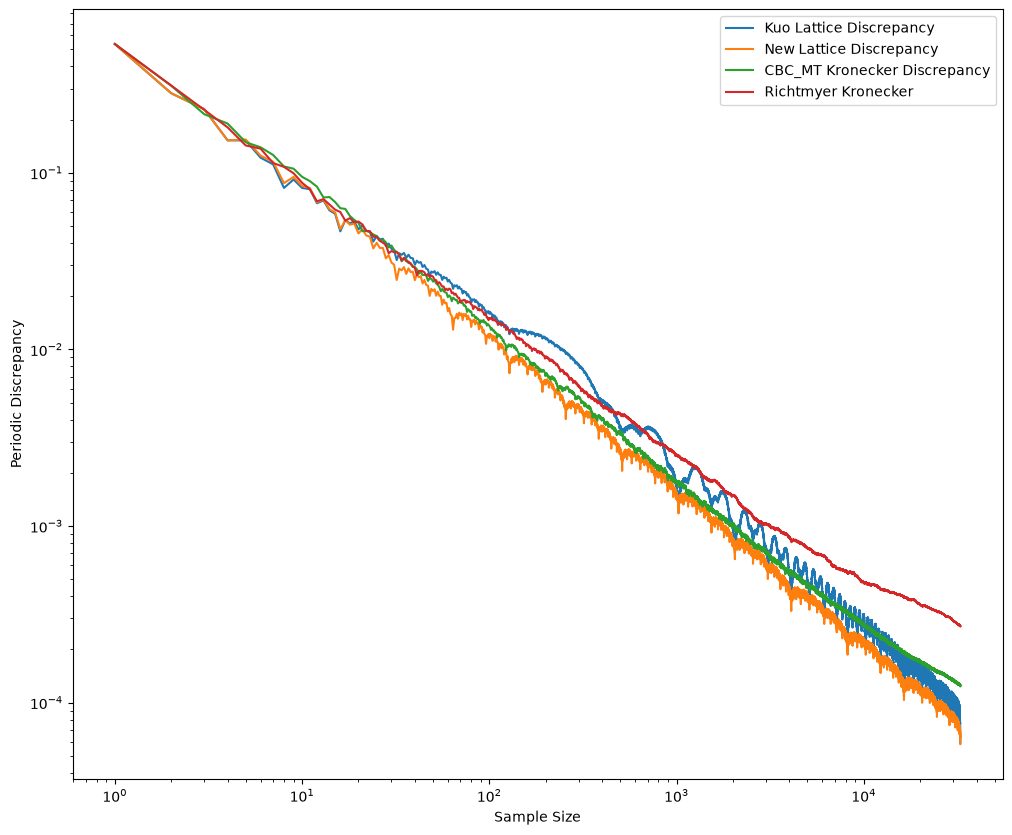

In [ ]:
lat1 = Lattice(dimension=dim, order="RADICAL_INVERSE", seed=12, generating_vector="kuo.lattice-39102-1024-1048576.3600.txt", m_max=20)
lat_discs1 = lat1.expected_squared_periodic_discrepancies(n_max=n, coord_weights=coord_weights)

lat2 = Lattice(dimension=dim, order="RADICAL_INVERSE", seed=12, generating_vector=np.uint64(searched_lattice_vector), m_max=20)
lat_discs2 = lat2.expected_squared_periodic_discrepancies(n_max=n, coord_weights=coord_weights)

kron2 = Kronecker(dimension=dim, generating_vector="RICHTMYER", seed=12)
kron_discs2 = kron2.expected_square_periodic_discrepancies(n_max = n, k_tilde = kron_k_tilde, gamma = coord_weights).reshape(-1)

# Note that the new lattice rule beats the Kuo lattice rule for low sample sizes, but they are comparable closer to n = 2^20.

fig, ax = pyplot.subplots(nrows=1, ncols=1, figsize=(12,10))
ax.plot(np.arange(1, n+1), np.sqrt(lat_discs1), label="Kuo Lattice Discrepancy")
ax.plot(np.arange(1, n+1), np.sqrt(lat_discs2), label="New Lattice Discrepancy")
ax.plot(np.arange(1, n+1), np.sqrt(kron_discs), label="CBC_MT Kronecker Discrepancy")
ax.plot(np.arange(1, n+1), np.sqrt(kron_discs2), label="Richtmyer Kronecker")
ax.set_xscale("log")
ax.set_yscale("log")
ax.legend()
ax.set_xlabel("Sample Size")
ax.set_ylabel("Periodic Discrepancy")